# SK hynix ADR / local relative value

### Accessing a structural premium, swap-financed and cross-margined

The US line trades above the identical Korean shares because new US shares require the
Company's consent and it has not given it. The market cannot arbitrage the gap away. We
manufacture the exposure.

$$\pi \;=\; \frac{P_{\text{ADR}}}{P_{\text{local}} \cdot \text{FX} / 10} \;-\; 1$$

*One ADR represents one-tenth of a common share. π is the object of everything that follows,
defined before anything is claimed about it.*

In [1]:
%matplotlib inline
import sys, pathlib, datetime as _dt
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import Markdown
from pipeline.viz import theme, figures
from pipeline.measurement.premium import build_all_variants
from pipeline.package import breakeven as BE, capacity as CAP, financing as FIN
from pipeline.package import margin_path as MP, netting as NET, scenarios as SC
from pipeline.hedging.ratios import HedgeLegs, fx_sensitivity
from pipeline.lab import tsmc as LAB
from scripts.export_client_pack import panels
from scripts.build_deck_v2 import extra_panels
from scripts.build_deck_v3 import economics_line
theme.apply()
PANELS = dict(panels()) | dict(extra_panels())

# Every number below is computed at render. Nothing on this page is typed.
sk   = build_all_variants("skhy")[0].series
tsm  = build_all_variants("tsmc")[0].series
bb   = build_all_variants("baba")[0].series
_5y  = pd.Timedelta(days=365 * 5)
PI    = float(sk.iloc[-1]) * 100
NORM  = float(tsm[tsm.index >= tsm.index[-1] - _5y].mean()) * 100
CTRL  = float(bb[bb.index >= bb.index[-1] - _5y].mean()) * 100
CARRY = FIN.carry_summary(); FED = FIN.fed_sensitivity()
LO    = FIN.carry_summary("low")["total_bp_per_month"]
HI    = FIN.carry_summary("high")["total_bp_per_month"]
BE_MO = CARRY["critical_carry_bp_per_month"]
ECON, ECON_NOTE = economics_line(BE.CARRY_BRACKET_BP)
EO    = LAB.entry_outcomes(LAB.premium(), pctiles=(0.90,), horizons=(252,)).set_index("bracket")
EX    = LAB.excursions(LAB.premium()); SKW = LAB.skhy_week_one_excursion()
FXS   = fx_sensitivity(HedgeLegs.live("skhy").premium)
PEAK  = MP.peak_call()
_cvs  = NET.calm_vs_stress().set_index("regime_label")
CALM  = float(_cvs.loc[[i for i in _cvs.index if i.startswith("calm")][0], "capital_saving"]) * 100
STRESS= float(_cvs.loc[[i for i in _cvs.index if i.startswith("stress")][0], "capital_saving"]) * 100
_days = CAP.days_to_unwind()
D1BN  = float(_days[(_days.participation == 0.10) & (_days.size_usd == 1e9)].days_binding.iloc[0])
ADV   = CAP.adv_table()
AS_OF = str(sk.index[-1].date())
print(f"rendered {AS_OF} — pi {PI:.2f}% | carry {LO:.0f}-{HI:.0f}bp/mo vs {BE_MO:.0f} breakeven")

rendered 2026-07-28 — pi 22.57% | carry 7-70bp/mo vs 80 breakeven


In [2]:
Markdown(f'''
| {PI:.1f}% | {NORM:.1f}% | {CTRL:.1f}% |
|---|---|---|
| **SK hynix today** | **TSMC, 5-year mean** — the structural comparable | **Alibaba** — supply fully fungible |

*Levels at {AS_OF}. Same construction for all three pairs.
Research: `github.com/ZinuoS/Charon`.*
''')


| 22.6% | 12.5% | -0.1% |
|---|---|---|
| **SK hynix today** | **TSMC, 5-year mean** — the structural comparable | **Alibaba** — supply fully fungible |

*Levels at 2026-07-28. Same construction for all three pairs.
Research: `github.com/ZinuoS/Charon`.*


## 1. The pitch

In [3]:
Markdown(f'''
**The trade.** Long 000660.KS through a total-return swap, short SKHY, FX-hedged through the
USD/KRW cross-currency structure, cross-margined as one ticket. You face us once.

**Entry.** {PI:.1f}%, against a five-year mean of {NORM:.1f}% for the closest structural
comparable and {CTRL:.1f}% for a pair whose share supply is fully fungible. That is the
relative-value anchor. It is a level comparison and it is not a forecast — nothing forces this
gap to close, and the mechanism section explains why we say so.

**Size.** $100mm reference. Capacity to roughly $1bn at 10% participation, with a
{D1BN:.1f}-session exit. Getting out is easy; borrowing the shares to get in is the constraint.

**The economics.** All-in carry is **{ECON} against an {BE_MO:.0f}bp/mo breakeven** — a modest
hurdle across the entire borrow range, because the funding leg is a
{abs(CARRY["funding_differential_bp"]):.0f}bp/yr **tailwind** rather than a cost. Return on
margin is quoted against illustrative 20% initial margin.

**What we charge**

| Component | Terms |
|---|---|
| Financing spread, both swap legs | indicative on request |
| Borrow | pass-through + spread; the {ECON} range is this line |
| Execution | indicative on request |
| FX | executed with the pair, not bolted on |

*{ECON_NOTE[0].upper() + ECON_NOTE[1:]}.*

**Why it holds, in three sentences.** It is **durable** because new ADRs need the Company's
consent, so supply cannot answer demand. It is **attractive** because 21.6 years of the nearest
comparable regime show elevated entries beating the carry
{EO.loc["low","frac_beats_carry"]:.0%} of the time at low borrow and
{EO.loc["mid","frac_beats_carry"]:.0%} at mid. It is **timely** because the ADR trades
\\${ADV.iloc[0].adv_usd/1e9:.1f}bn a day after twelve sessions against
\\${ADV.iloc[1].adv_usd/1e9:.1f}bn for a line with 2,838 sessions of history, and the funding
leg gets cheaper if the Fed hikes.
''')


**The trade.** Long 000660.KS through a total-return swap, short SKHY, FX-hedged through the
USD/KRW cross-currency structure, cross-margined as one ticket. You face us once.

**Entry.** 22.6%, against a five-year mean of 12.5% for the closest structural
comparable and -0.1% for a pair whose share supply is fully fungible. That is the
relative-value anchor. It is a level comparison and it is not a forecast — nothing forces this
gap to close, and the mechanism section explains why we say so.

**Size.** $100mm reference. Capacity to roughly $1bn at 10% participation, with a
1.2-session exit. Getting out is easy; borrowing the shares to get in is the constraint.

**The economics.** All-in carry is **7-70bp/mo against an 80bp/mo breakeven** — a modest
hurdle across the entire borrow range, because the funding leg is a
72bp/yr **tailwind** rather than a cost. Return on
margin is quoted against illustrative 20% initial margin.

**What we charge**

| Component | Terms |
|---|---|
| Financing spread, both swap legs | indicative on request |
| Borrow | pass-through + spread; the 7-70bp/mo range is this line |
| Execution | indicative on request |
| FX | executed with the pair, not bolted on |

*Range, not a quote — it is the ADR borrow spread, and it is the one component still awaiting the desk.*

**Why it holds, in three sentences.** It is **durable** because new ADRs need the Company's
consent, so supply cannot answer demand. It is **attractive** because 21.6 years of the nearest
comparable regime show elevated entries beating the carry
56% of the time at low borrow and
42% at mid. It is **timely** because the ADR trades
\$8.8bn a day after twelve sessions against
\$8.3bn for a line with 2,838 sessions of history, and the funding
leg gets cheaper if the Fed hikes.


## 2. Why the premium exists

**The gap is structural, not a mispricing waiting to be traded away.**

Cancelling an ADR into local shares is a holder right. It always works, it costs seven basis
points round trip, and it puts a floor under the premium.

Creating an ADR is the other direction, and it requires the Company to consent to a larger
deposit. It has not. So the arbitrage that would normally close a gap like this can only push
one way.

That asymmetry is the whole opportunity. A premium with a functioning floor and a ceiling that
is somebody's decision does not converge on its own — and we do not claim it does. What it does
is persist, which is what makes it available to hold.

**You cannot reach it by converting.** The direction that would capture the gap is the one
that is shut. You reach it by holding the spread, and that is what we build.

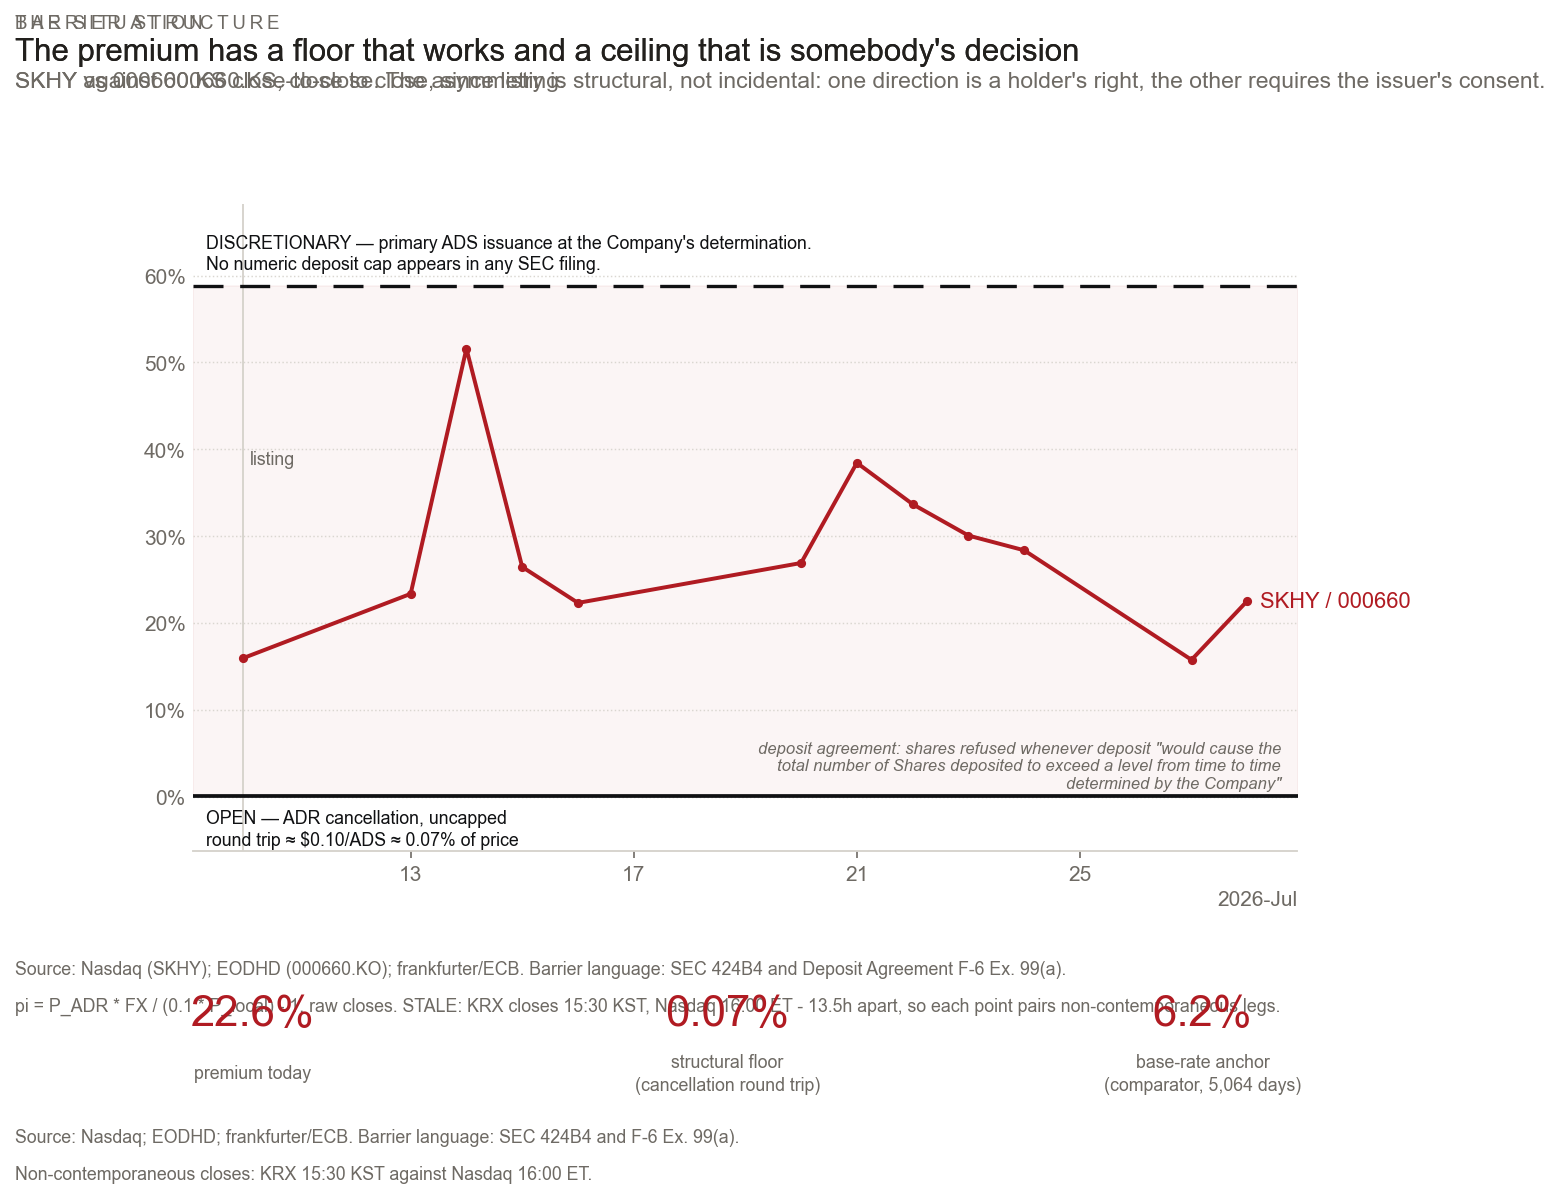

In [4]:
fig, _ = PANELS["P1_situation"]()
fig;

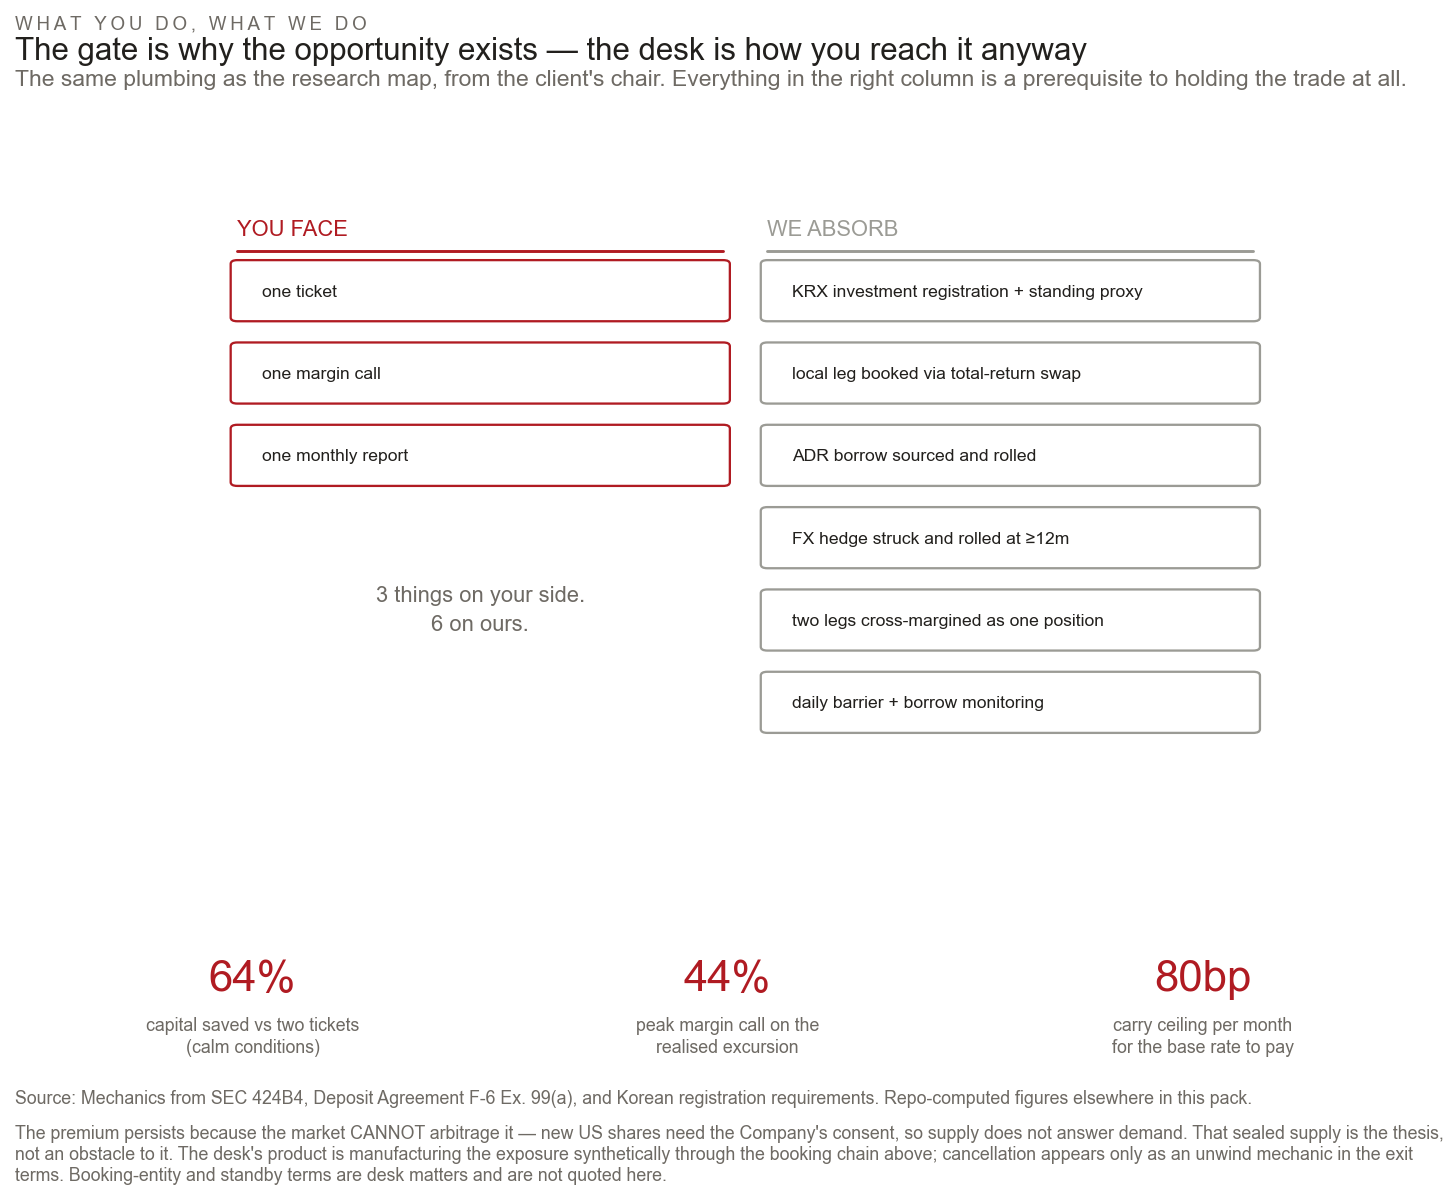

In [5]:
fig, _ = PANELS["P2_structure"]()
fig;

## 3. Where it sits

In [6]:
Markdown(f'''
**{PI - NORM:.0f} points wide of the structural comparable.** The anchor below is three pairs
of the same instrument type at three levels, and one structural fact explains the spread
between them: whether the supply of US shares can respond to demand.
''')


**10 points wide of the structural comparable.** The anchor below is three pairs
of the same instrument type at three levels, and one structural fact explains the spread
between them: whether the supply of US shares can respond to demand.


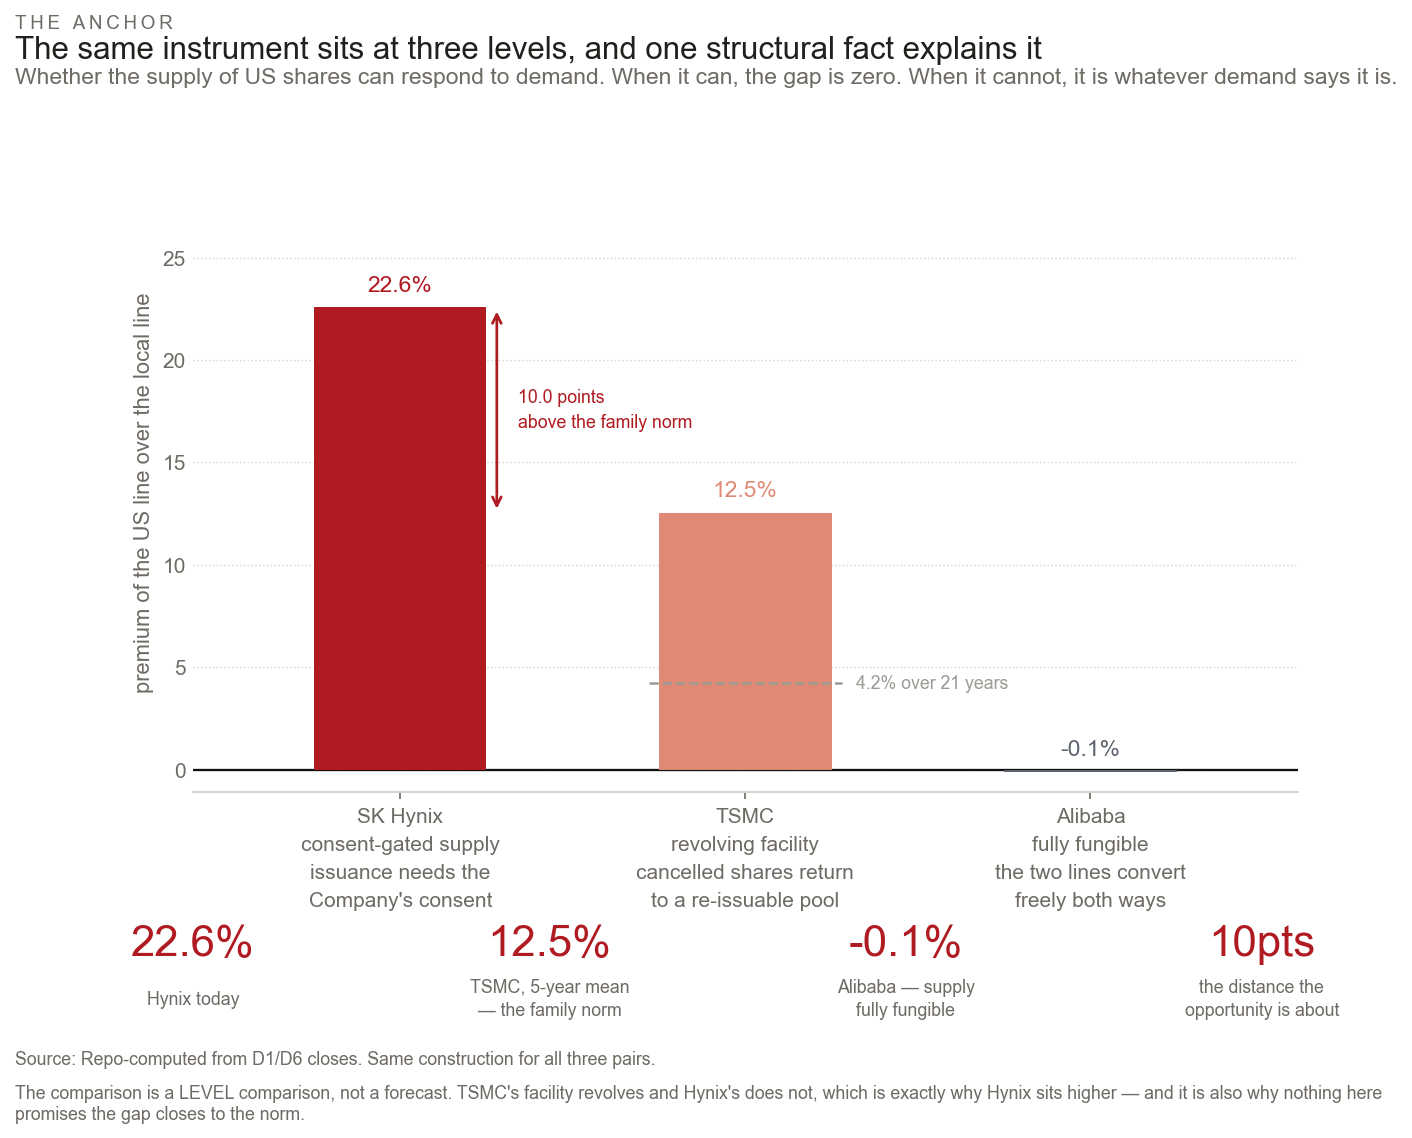

In [7]:
fig, _ = PANELS["S01a_anchor"]()
fig;

In [8]:
Markdown(f'''
**The historical case, stated exactly.** Entering at the 90th percentile of the premium's own
history and holding a year, across 21.6 years of the nearest comparable regime:

| Borrow bracket | Beat the carry |
|---|---|
| low | **{EO.loc["low","frac_beats_carry"]:.0%}** |
| mid | **{EO.loc["mid","frac_beats_carry"]:.0%}** |
| high | **{EO.loc["high","frac_beats_carry"]:.0%}** |

Elevated entries beat the carry in the majority of history at low borrow. At mid they do not,
and at high they clearly do not — **the cost bracket decides this trade, not the timing**, which
is exactly why the financing conversation is the one worth having. The entry rule triggers on an
expanding percentile so it never sees its own future, and every grid cell is reported.

**How these gaps have closed.** Over 21.6 years the comparable pair produced
{int(LAB.census(frame=LAB.legs()).query("min_move_pp==5.0 and min_days==10").iloc[0].n_episodes)}
episodes at the base rule. Compressions closed through the US leg falling more often than
through the local leg rising — which is why the short-ADR expression is the primary one on the
term sheet. Full distributions are in the appendix, not hidden.
''')


**The historical case, stated exactly.** Entering at the 90th percentile of the premium's own
history and holding a year, across 21.6 years of the nearest comparable regime:

| Borrow bracket | Beat the carry |
|---|---|
| low | **56%** |
| mid | **42%** |
| high | **16%** |

Elevated entries beat the carry in the majority of history at low borrow. At mid they do not,
and at high they clearly do not — **the cost bracket decides this trade, not the timing**, which
is exactly why the financing conversation is the one worth having. The entry rule triggers on an
expanding percentile so it never sees its own future, and every grid cell is reported.

**How these gaps have closed.** Over 21.6 years the comparable pair produced
137
episodes at the base rule. Compressions closed through the US leg falling more often than
through the local leg rising — which is why the short-ADR expression is the primary one on the
term sheet. Full distributions are in the appendix, not hidden.


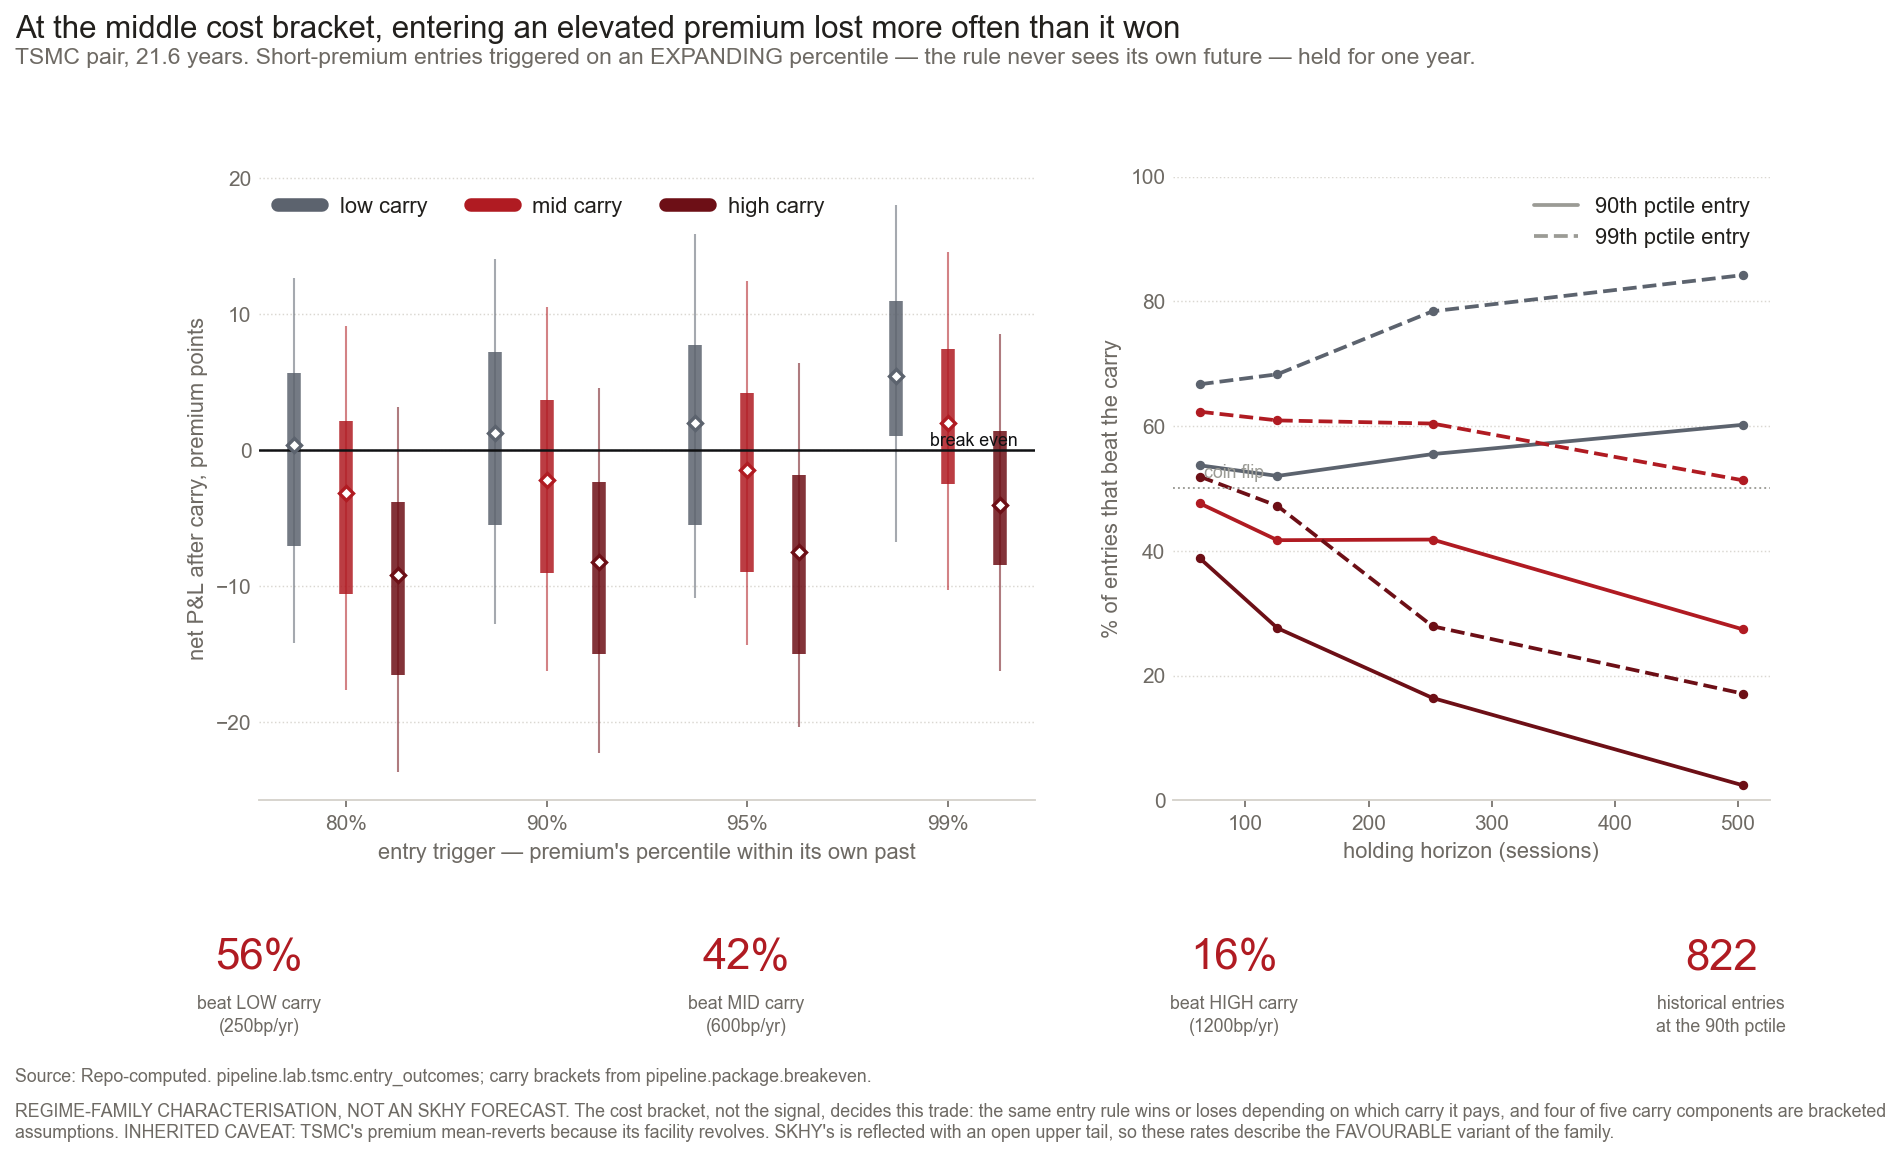

In [9]:
fig, _ = PANELS["P8c_lab_outcomes"]()
fig;

## 4. Why now

In [10]:
Markdown(f'''
**(i) The bid.** The ADR is three weeks old and trades \\${ADV.iloc[0].adv_usd/1e9:.1f}bn a day
— more than the Korean line's \\${ADV.iloc[1].adv_usd/1e9:.1f}bn, which has 2,838 sessions of
history. US demand meets a supply that cannot answer it. The twelve-session caveat travels with
that number and is printed on the capacity table.

**(ii) The cost, and it points the friendly way.** The carry decomposes into a measured
funding differential of **{CARRY["funding_differential_bp"]:+.0f}bp/yr** — a credit, not a
charge — plus the ADR borrow spread, which is the desk quote, plus documented fees. A 25bp
**hike makes this {FED["bp_per_month_per_25bp"]:.1f}bp per month cheaper** to hold, not dearer.
The funding leg is long the front end, so it hedges rather than compounds the macro.

**(iii) The channel.** The won moves the premium's level by
{FXS["empirical_central_pct_pts"]:.2f} points per 1%
(95% CI {FXS["empirical_range_pct_pts"][0]:.2f}–{FXS["empirical_range_pct_pts"][1]:.2f}), and
explains {FXS["fx_share_of_daily_premium_variance"]:.1%} of daily premium variation. We
registered the stronger claim — that won strength selects which leg closes the gap — and tested
it twice. On the comparable pair alone: +16.5 points in the predicted direction at p = 0.25.
Pooled across the panel: an odds ratio of 1.31 at p = 0.53, the effect shrinking as the sample
grew. **We are not pitching the won as a signal**, and we hold the caveat that all four
constrained comparables are Taiwanese.
''')


**(i) The bid.** The ADR is three weeks old and trades \$8.8bn a day
— more than the Korean line's \$8.3bn, which has 2,838 sessions of
history. US demand meets a supply that cannot answer it. The twelve-session caveat travels with
that number and is printed on the capacity table.

**(ii) The cost, and it points the friendly way.** The carry decomposes into a measured
funding differential of **-72bp/yr** — a credit, not a
charge — plus the ADR borrow spread, which is the desk quote, plus documented fees. A 25bp
**hike makes this 2.1bp per month cheaper** to hold, not dearer.
The funding leg is long the front end, so it hedges rather than compounds the macro.

**(iii) The channel.** The won moves the premium's level by
1.05 points per 1%
(95% CI 0.80–1.30), and
explains 1.3% of daily premium variation. We
registered the stronger claim — that won strength selects which leg closes the gap — and tested
it twice. On the comparable pair alone: +16.5 points in the predicted direction at p = 0.25.
Pooled across the panel: an odds ratio of 1.31 at p = 0.53, the effect shrinking as the sample
grew. **We are not pitching the won as a signal**, and we hold the caveat that all four
constrained comparables are Taiwanese.


$$C \;=\; \underbrace{(r_{\text{KRW}} - r_{\text{USD}})}_{\text{measured — FRED, native frequency}}
\;+\; \underbrace{s_{\text{borrow}}}_{\text{desk quote, bracketed}}
\;+\; \underbrace{f}_{\text{documented, 7bp round trip}}$$

*Each term points at its source. The one that spans a range is the borrow, and it is the one
the desk conversation closes.*

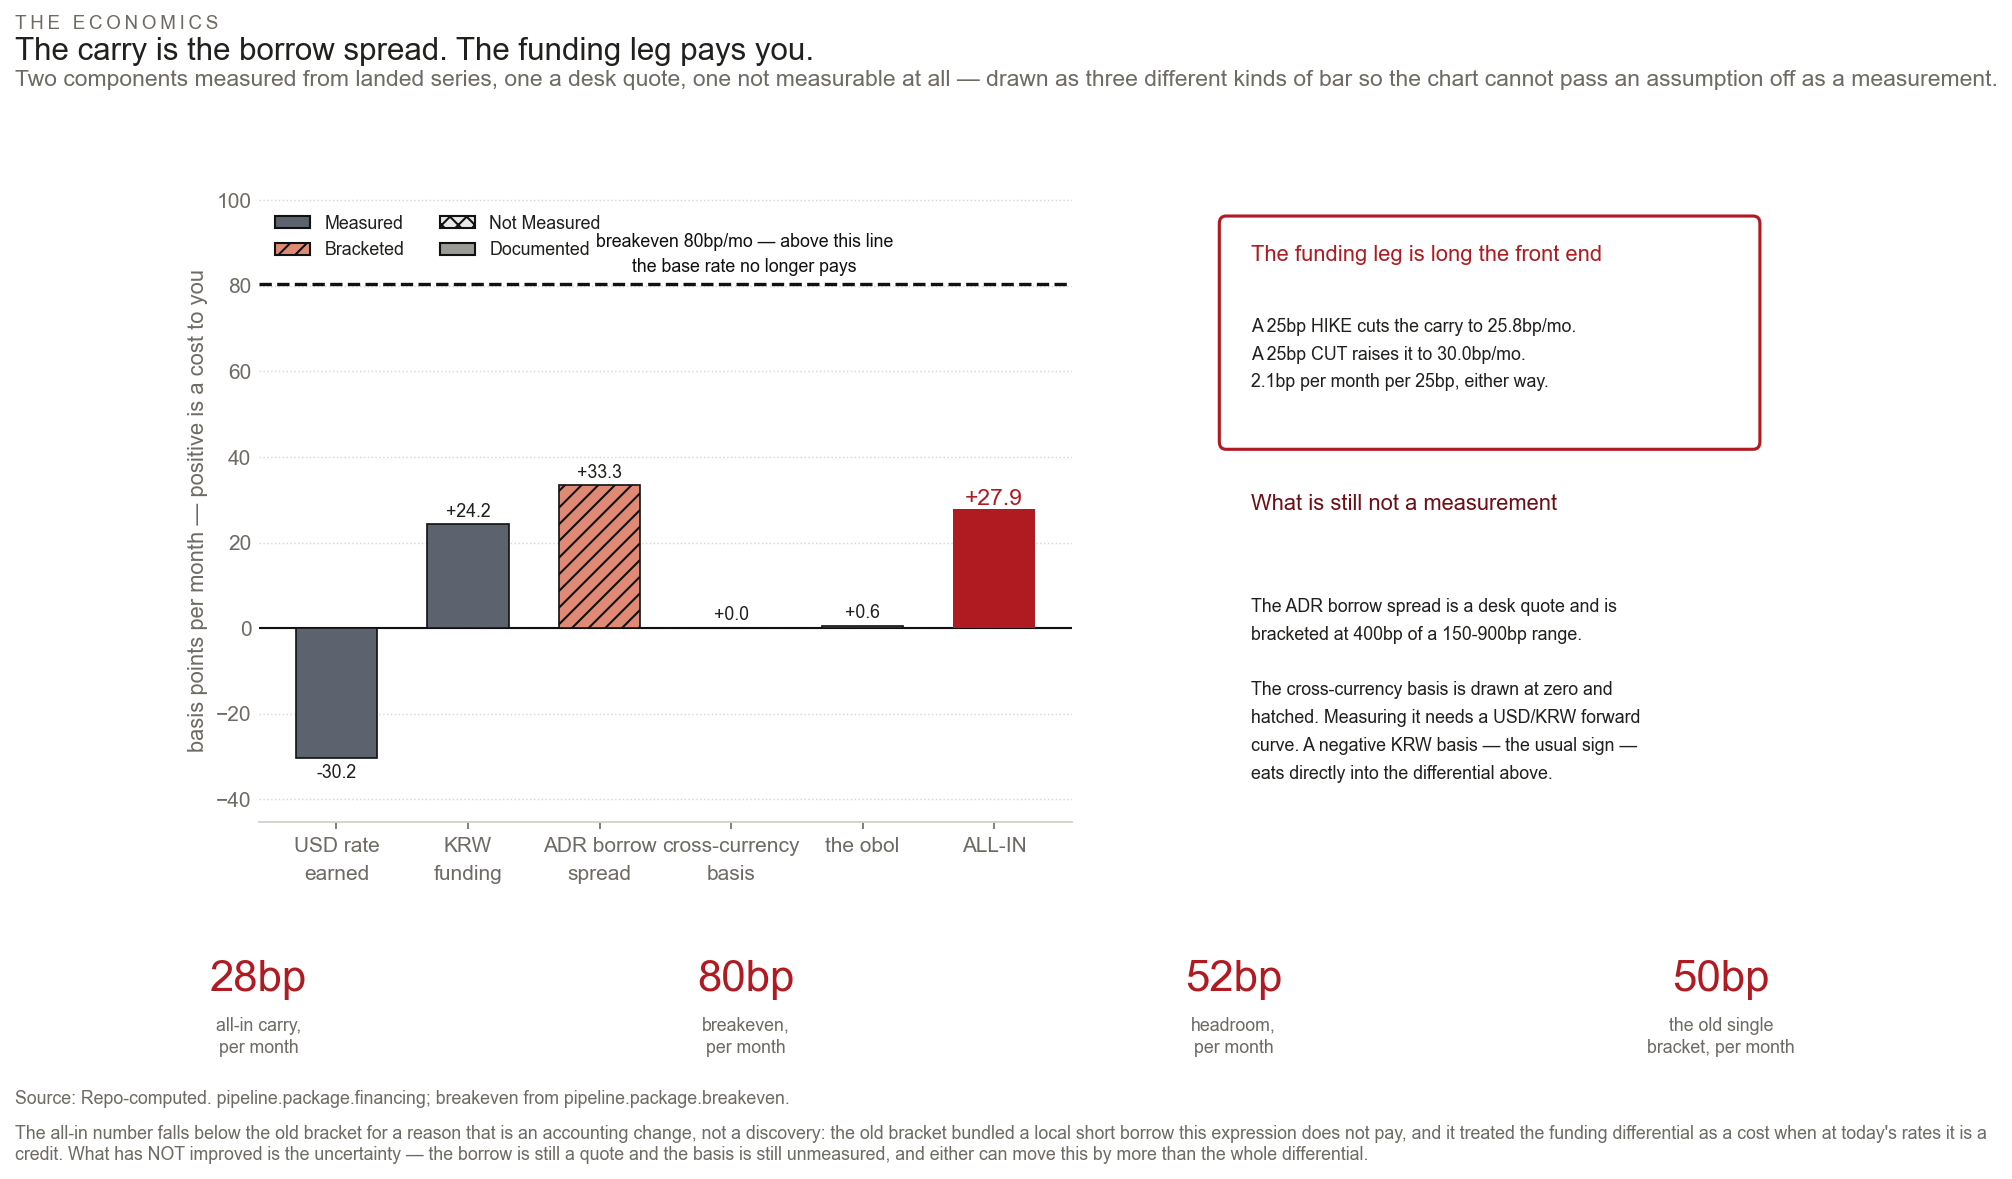

In [11]:
fig, _ = PANELS["S0A6_financing"]()
fig;

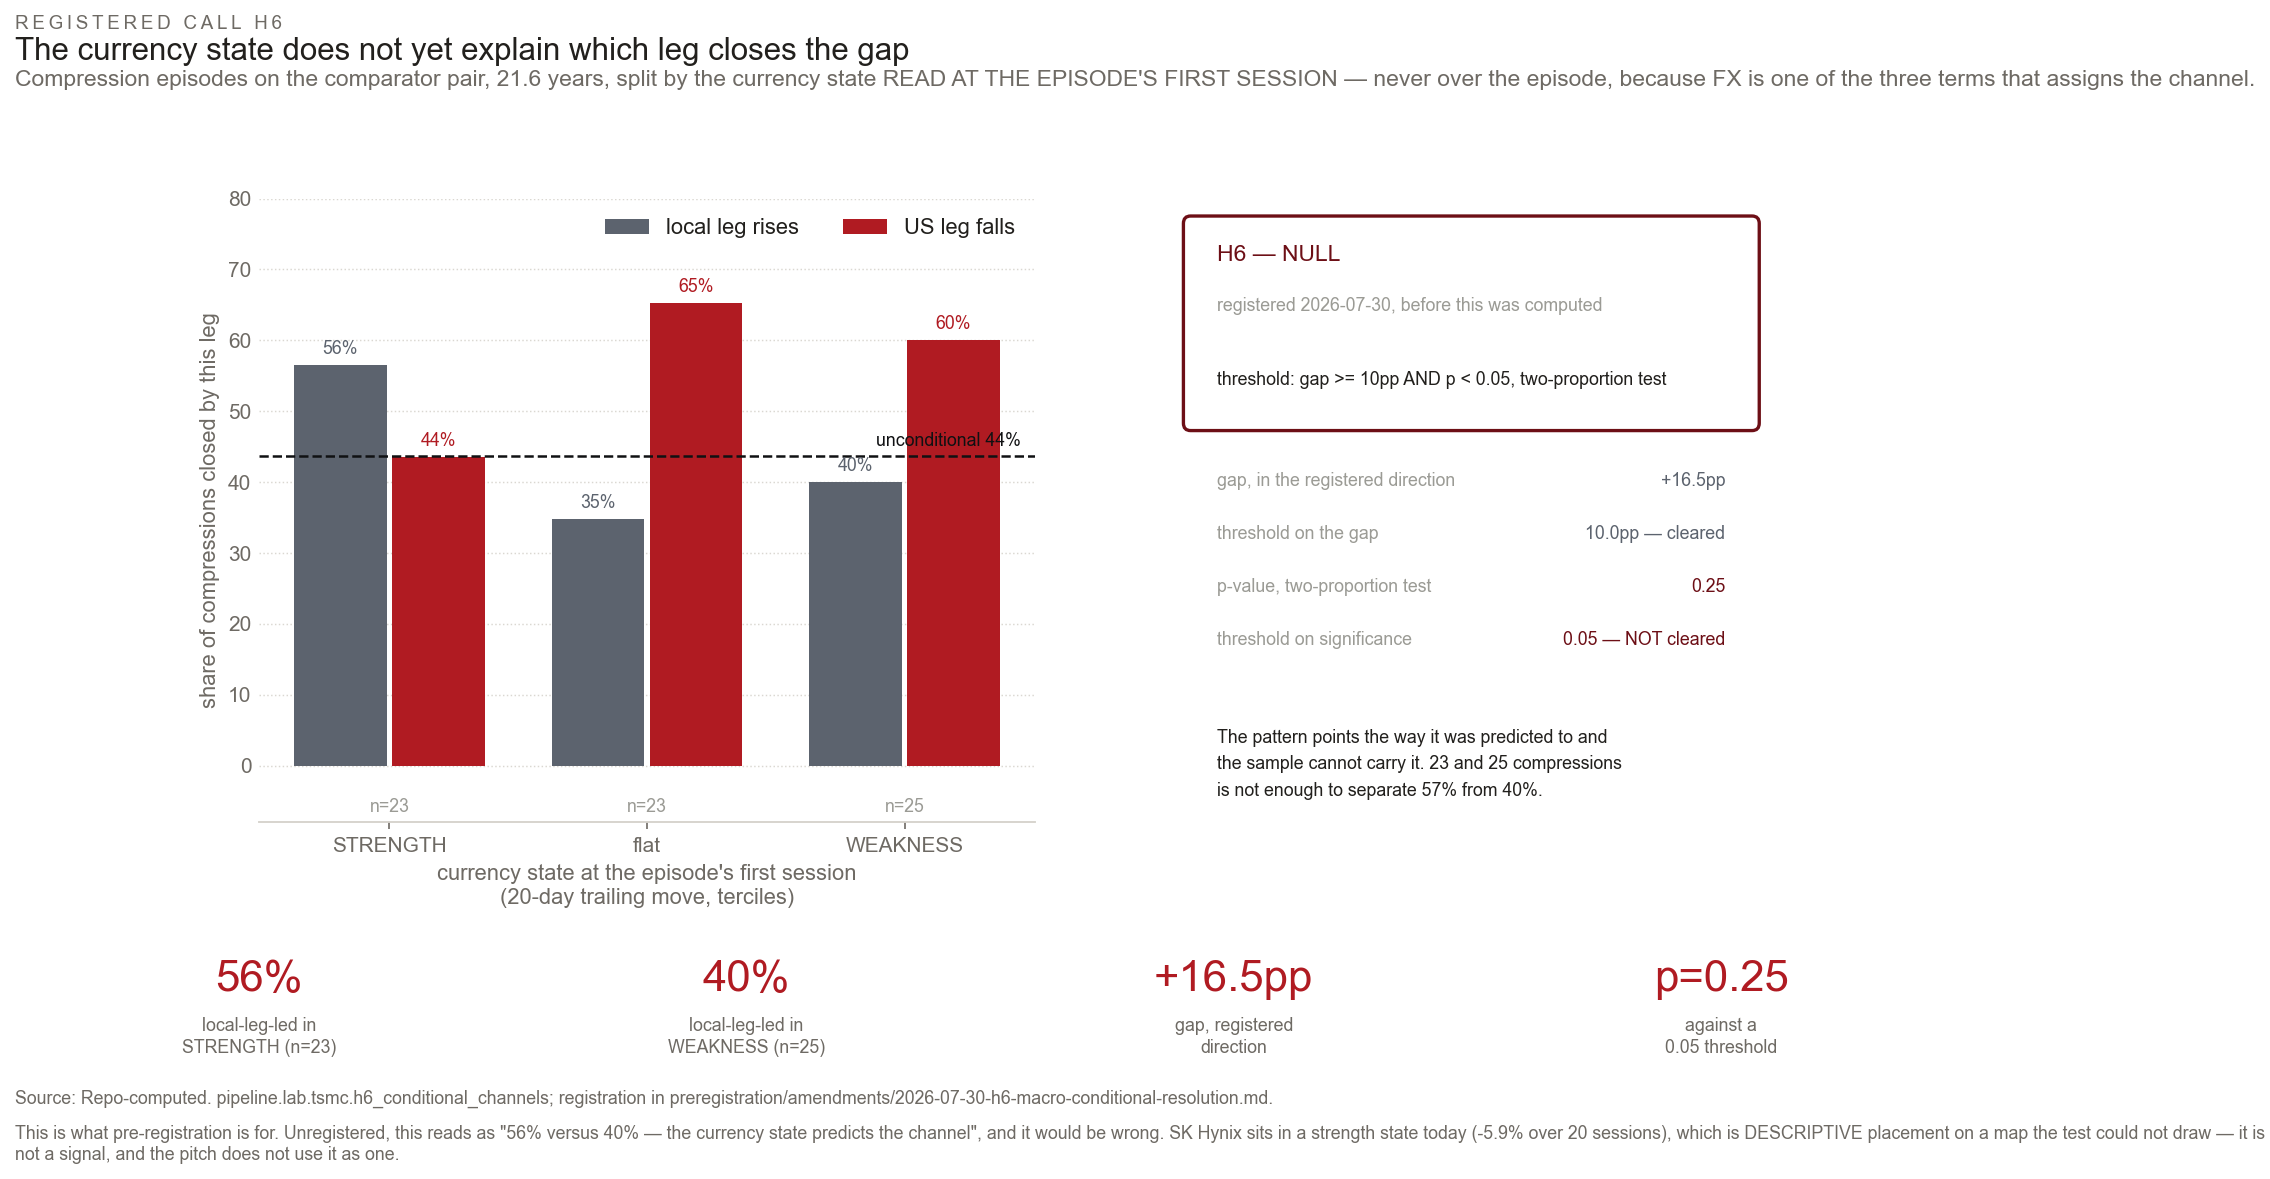

In [12]:
fig, _ = PANELS["S03a_macro_map"]()
fig;

## 5. The structure, and what we provide

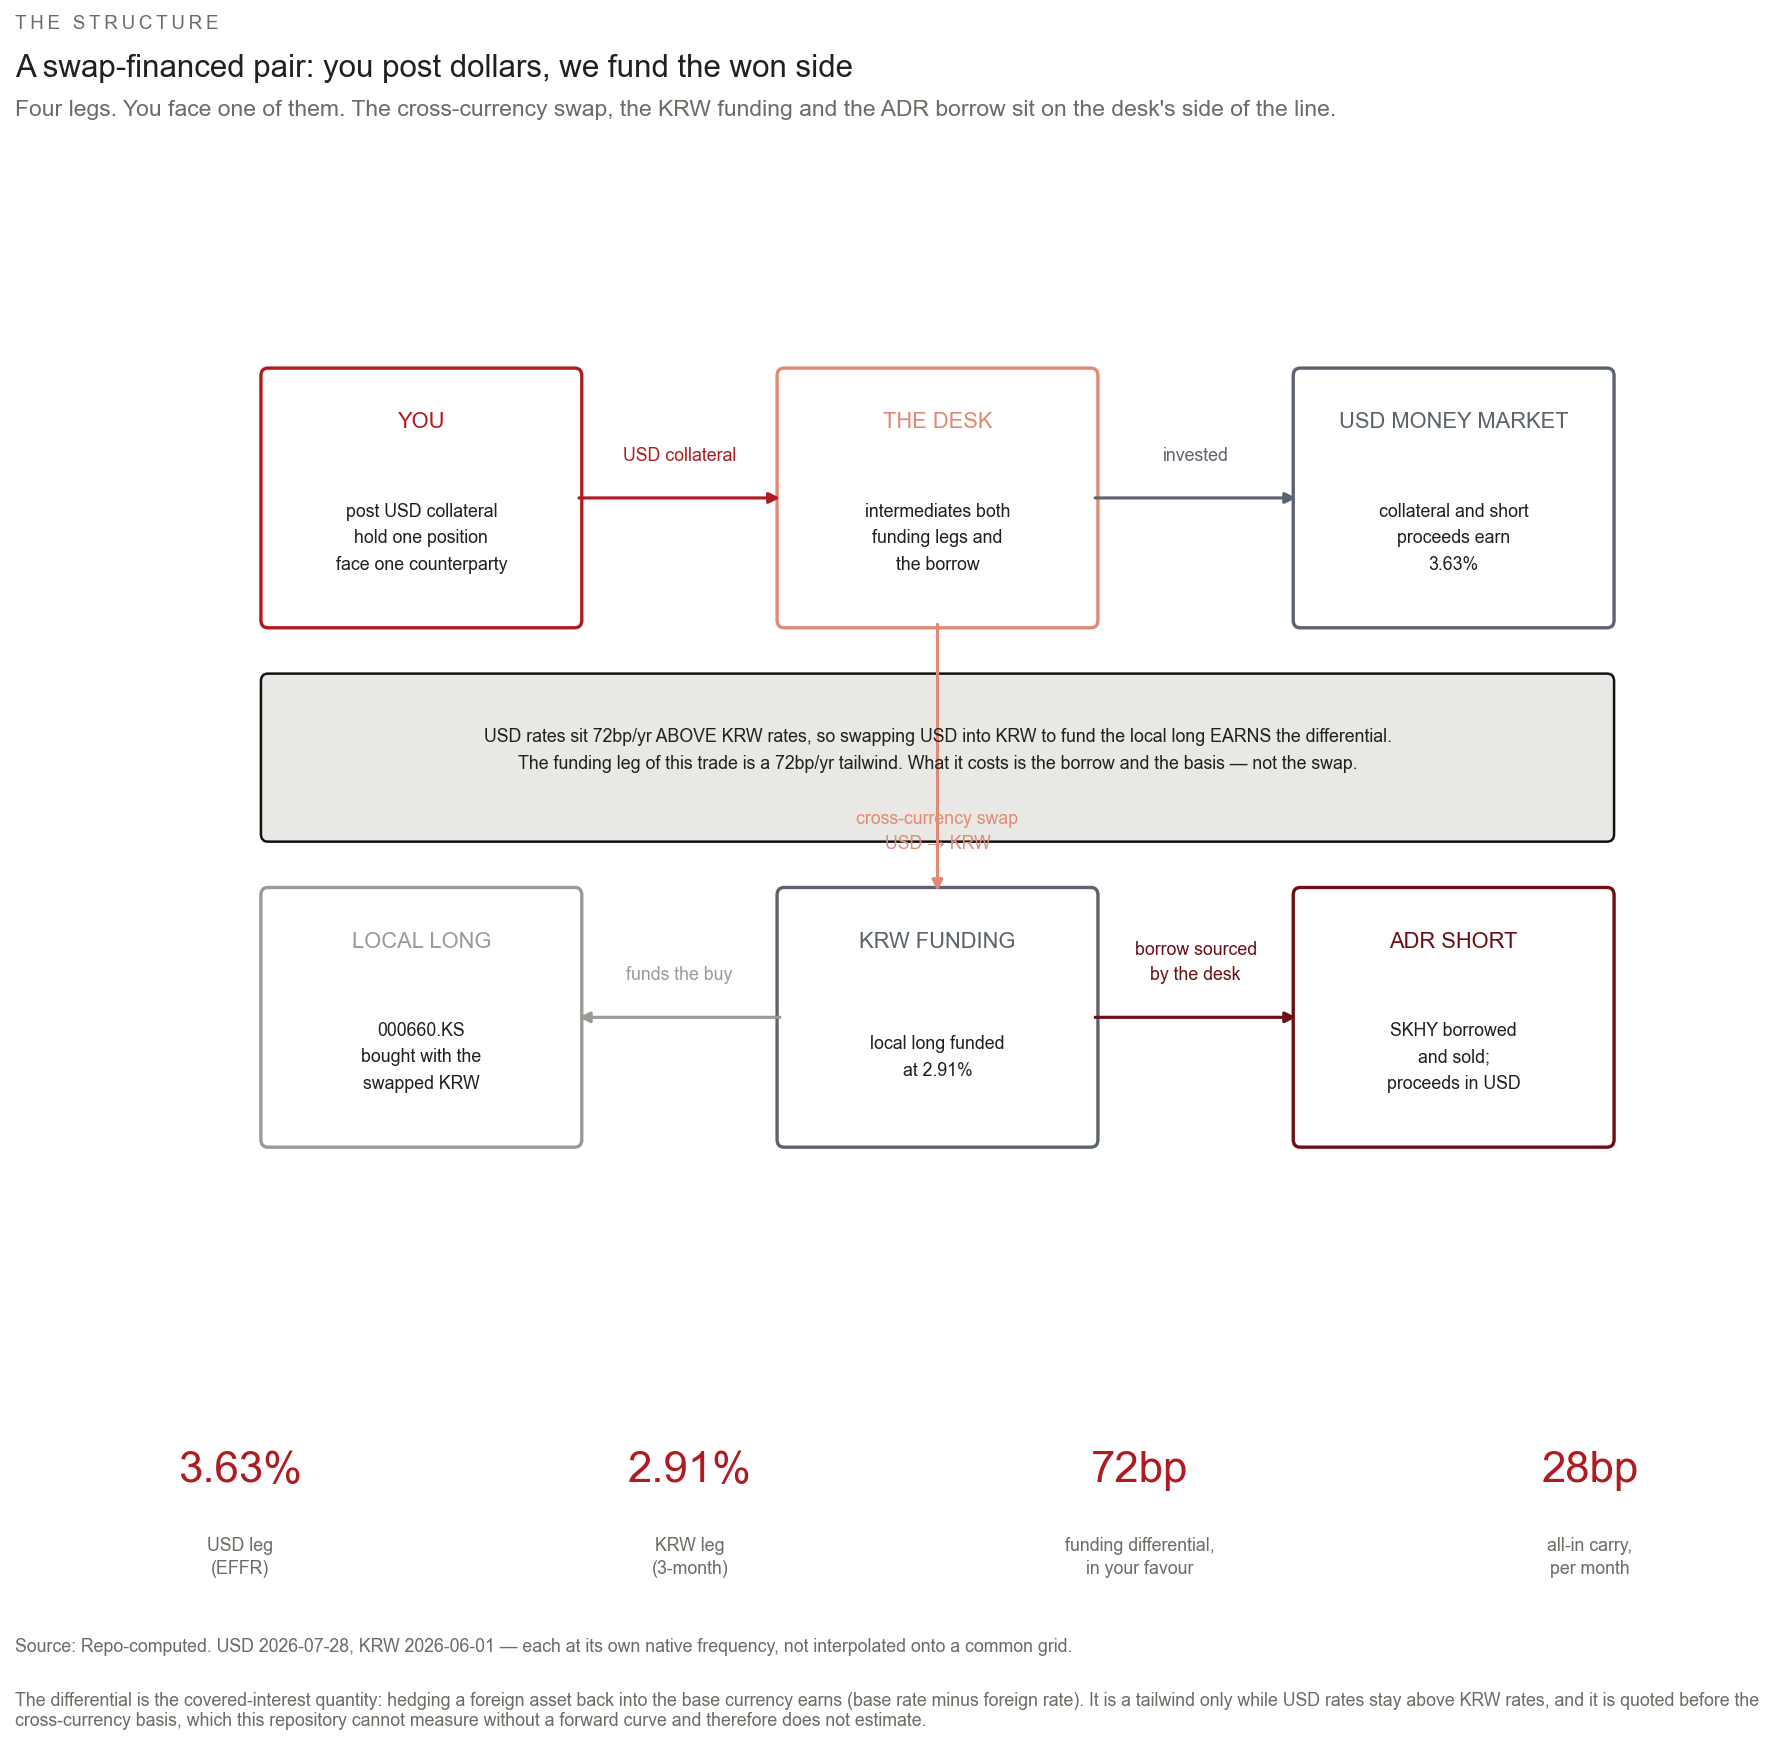

In [13]:
fig, _ = PANELS["S0A6b_structure"]()
fig;

In [14]:
Markdown(f'''
| You get | We absorb |
|---|---|
| One ticket | Korean market registration |
| One margin call | ADR borrow sourcing and recall risk |
| One report | Both swap funding legs |
| One counterparty | FX execution and the booking chain |

**Cross-margining.** One netted ticket instead of two saves **{CALM:.0f}% of capital on
ordinary days**. Through the worst week this pair has actually seen it called
**{PEAK["peak_total_pair_pct"]*100:.0f} cents on the dollar against
{PEAK["peak_total_standalone_pct"]*100:.0f} standalone** — {(1 - PEAK["peak_total_pair_pct"]/PEAK["peak_total_standalone_pct"])*100:.0f}%
less capital through the stress itself. On the top 20% of move days the saving is
{max(STRESS,0):.0f}%: the legs stop offsetting exactly when the gap jumps. We say so because you
will see it on the statement.

**Capacity.** {D1BN:.1f} sessions to build $1bn at 10% participation, borrow-bound rather than
exit-bound.

**Monitoring.** Monthly: the gap, the valve, and three registered items that either happened or
did not.
''')


| You get | We absorb |
|---|---|
| One ticket | Korean market registration |
| One margin call | ADR borrow sourcing and recall risk |
| One report | Both swap funding legs |
| One counterparty | FX execution and the booking chain |

**Cross-margining.** One netted ticket instead of two saves **63% of capital on
ordinary days**. Through the worst week this pair has actually seen it called
**44 cents on the dollar against
60 standalone** — 27%
less capital through the stress itself. On the top 20% of move days the saving is
0%: the legs stop offsetting exactly when the gap jumps. We say so because you
will see it on the statement.

**Capacity.** 1.2 sessions to build $1bn at 10% participation, borrow-bound rather than
exit-bound.

**Monitoring.** Monthly: the gap, the valve, and three registered items that either happened or
did not.


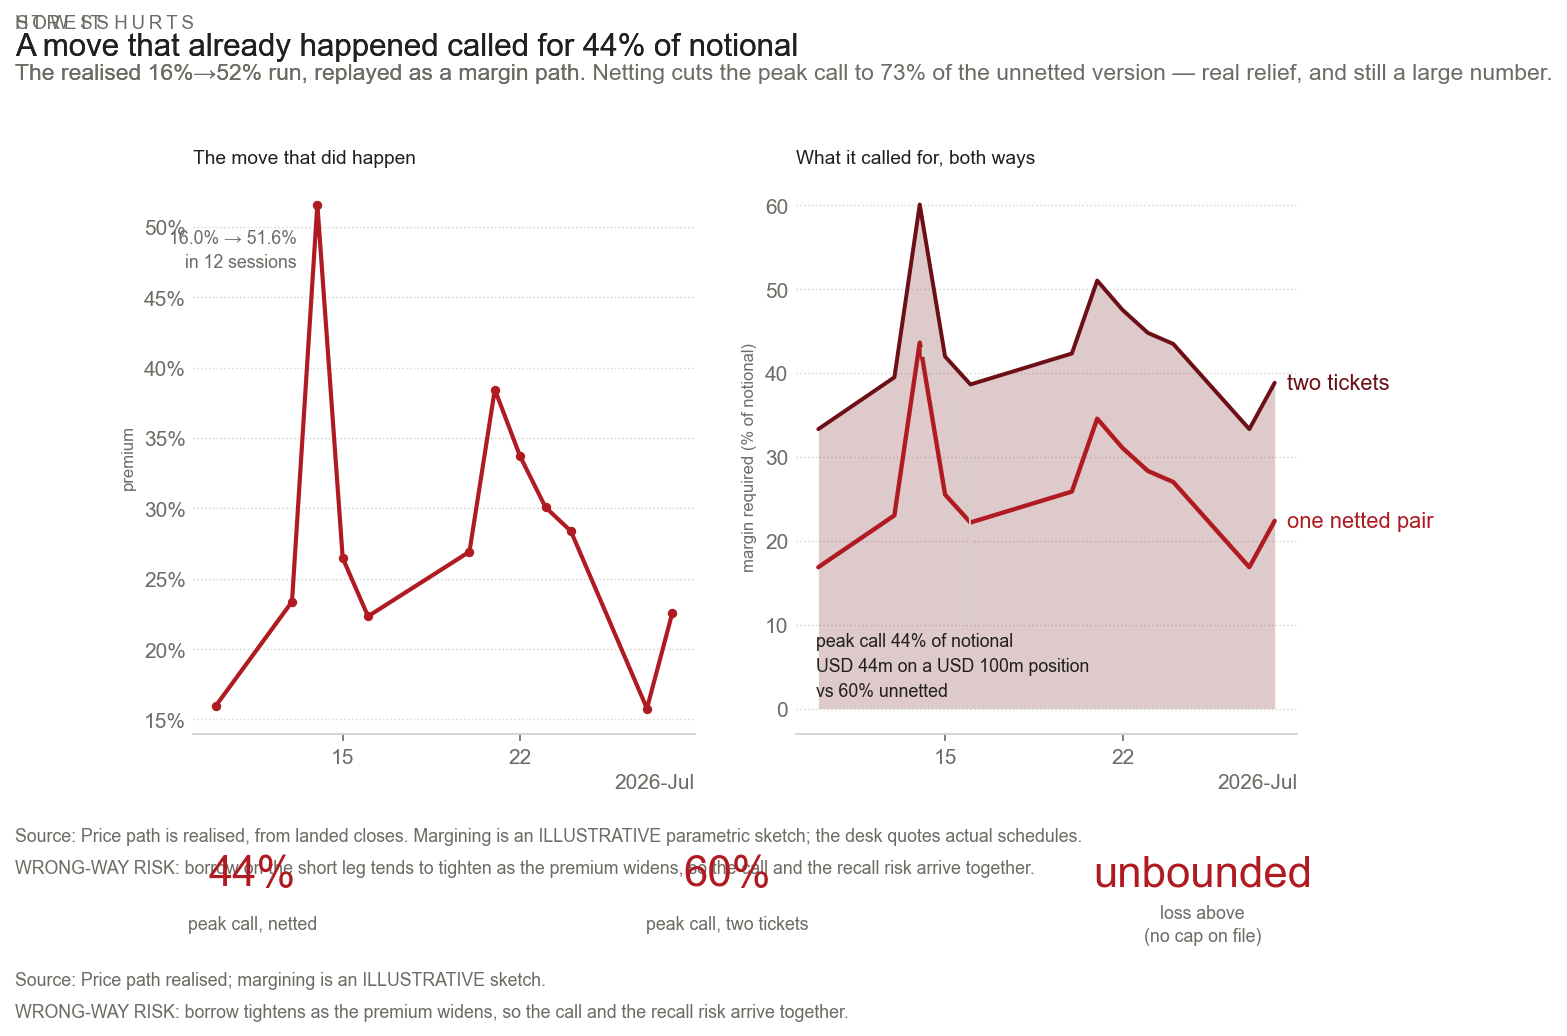

In [15]:
fig, _ = PANELS["P4b_margin_path"]()
fig;

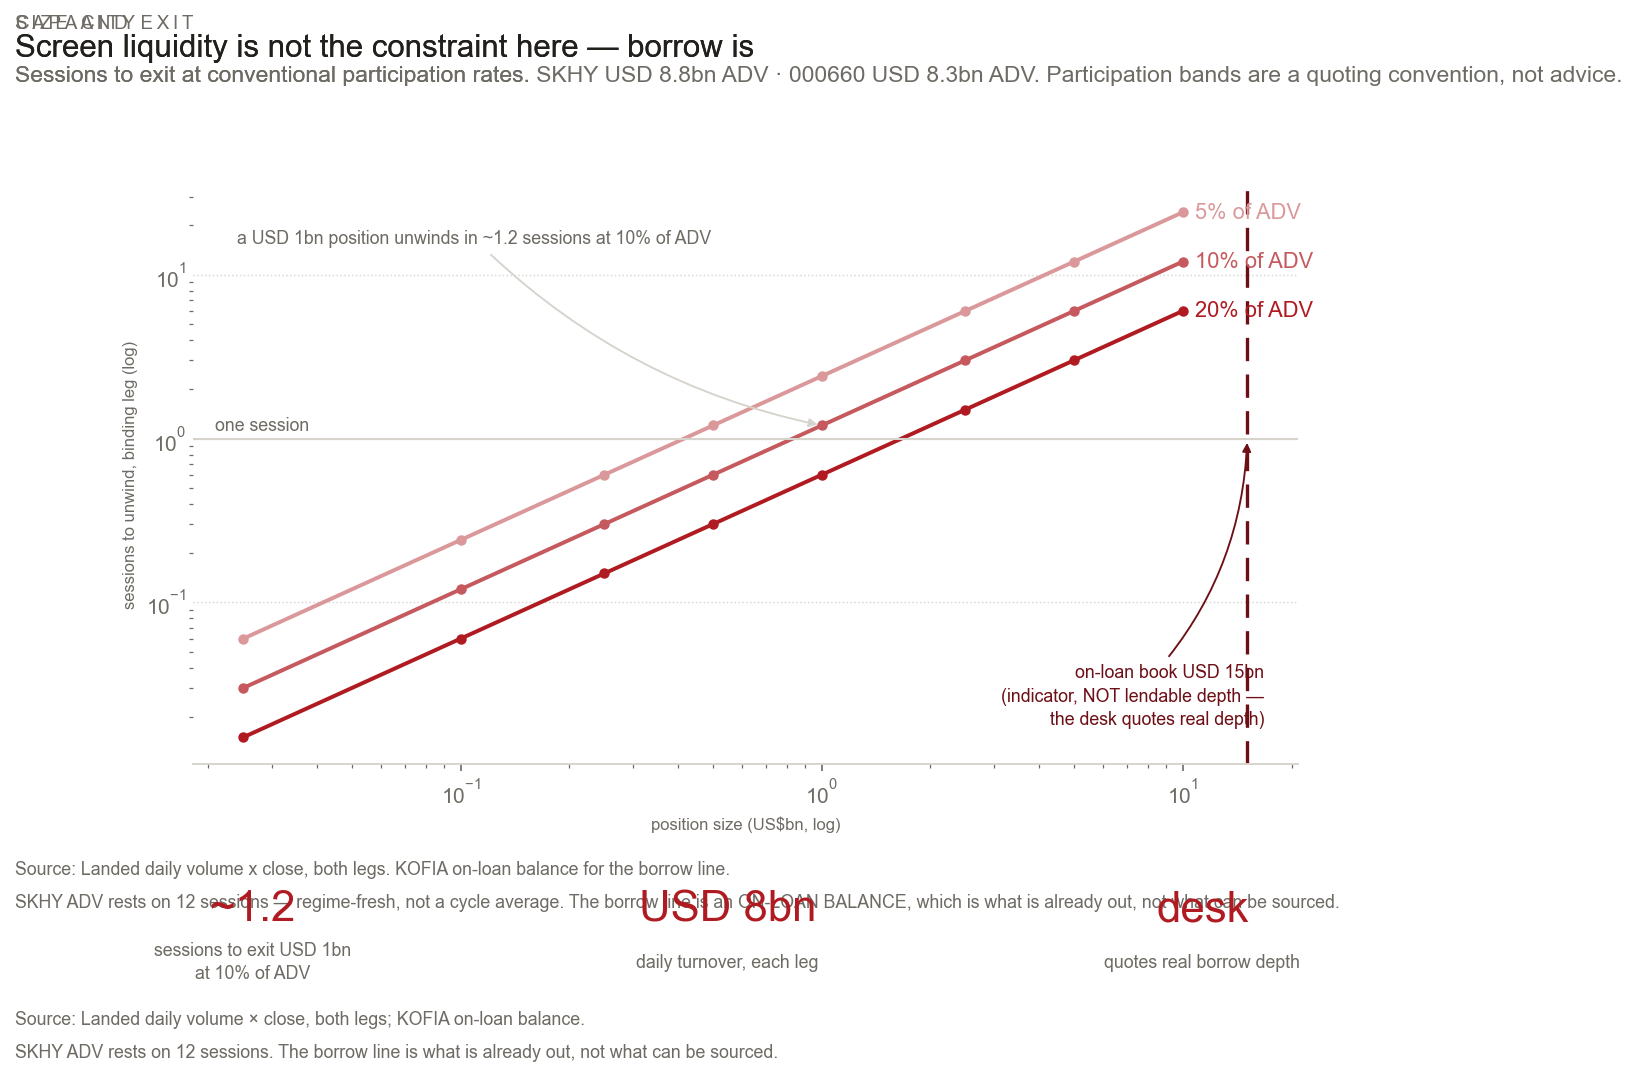

In [16]:
fig, _ = PANELS["P5_size_and_exit"]()
fig;

## 6. P&L scenarios

The identity, before the table:

$$\text{P\&L} \;=\; \Delta\pi \cdot N \;-\; C \cdot t, \qquad \text{ROM} \;=\; \frac{\text{P\&L}}{\text{IM}}$$

Two terms and no third. Δπ is the opportunity leg and has no assumed drift. C is the carry,
which accrues whatever happens and is the only component known in advance.

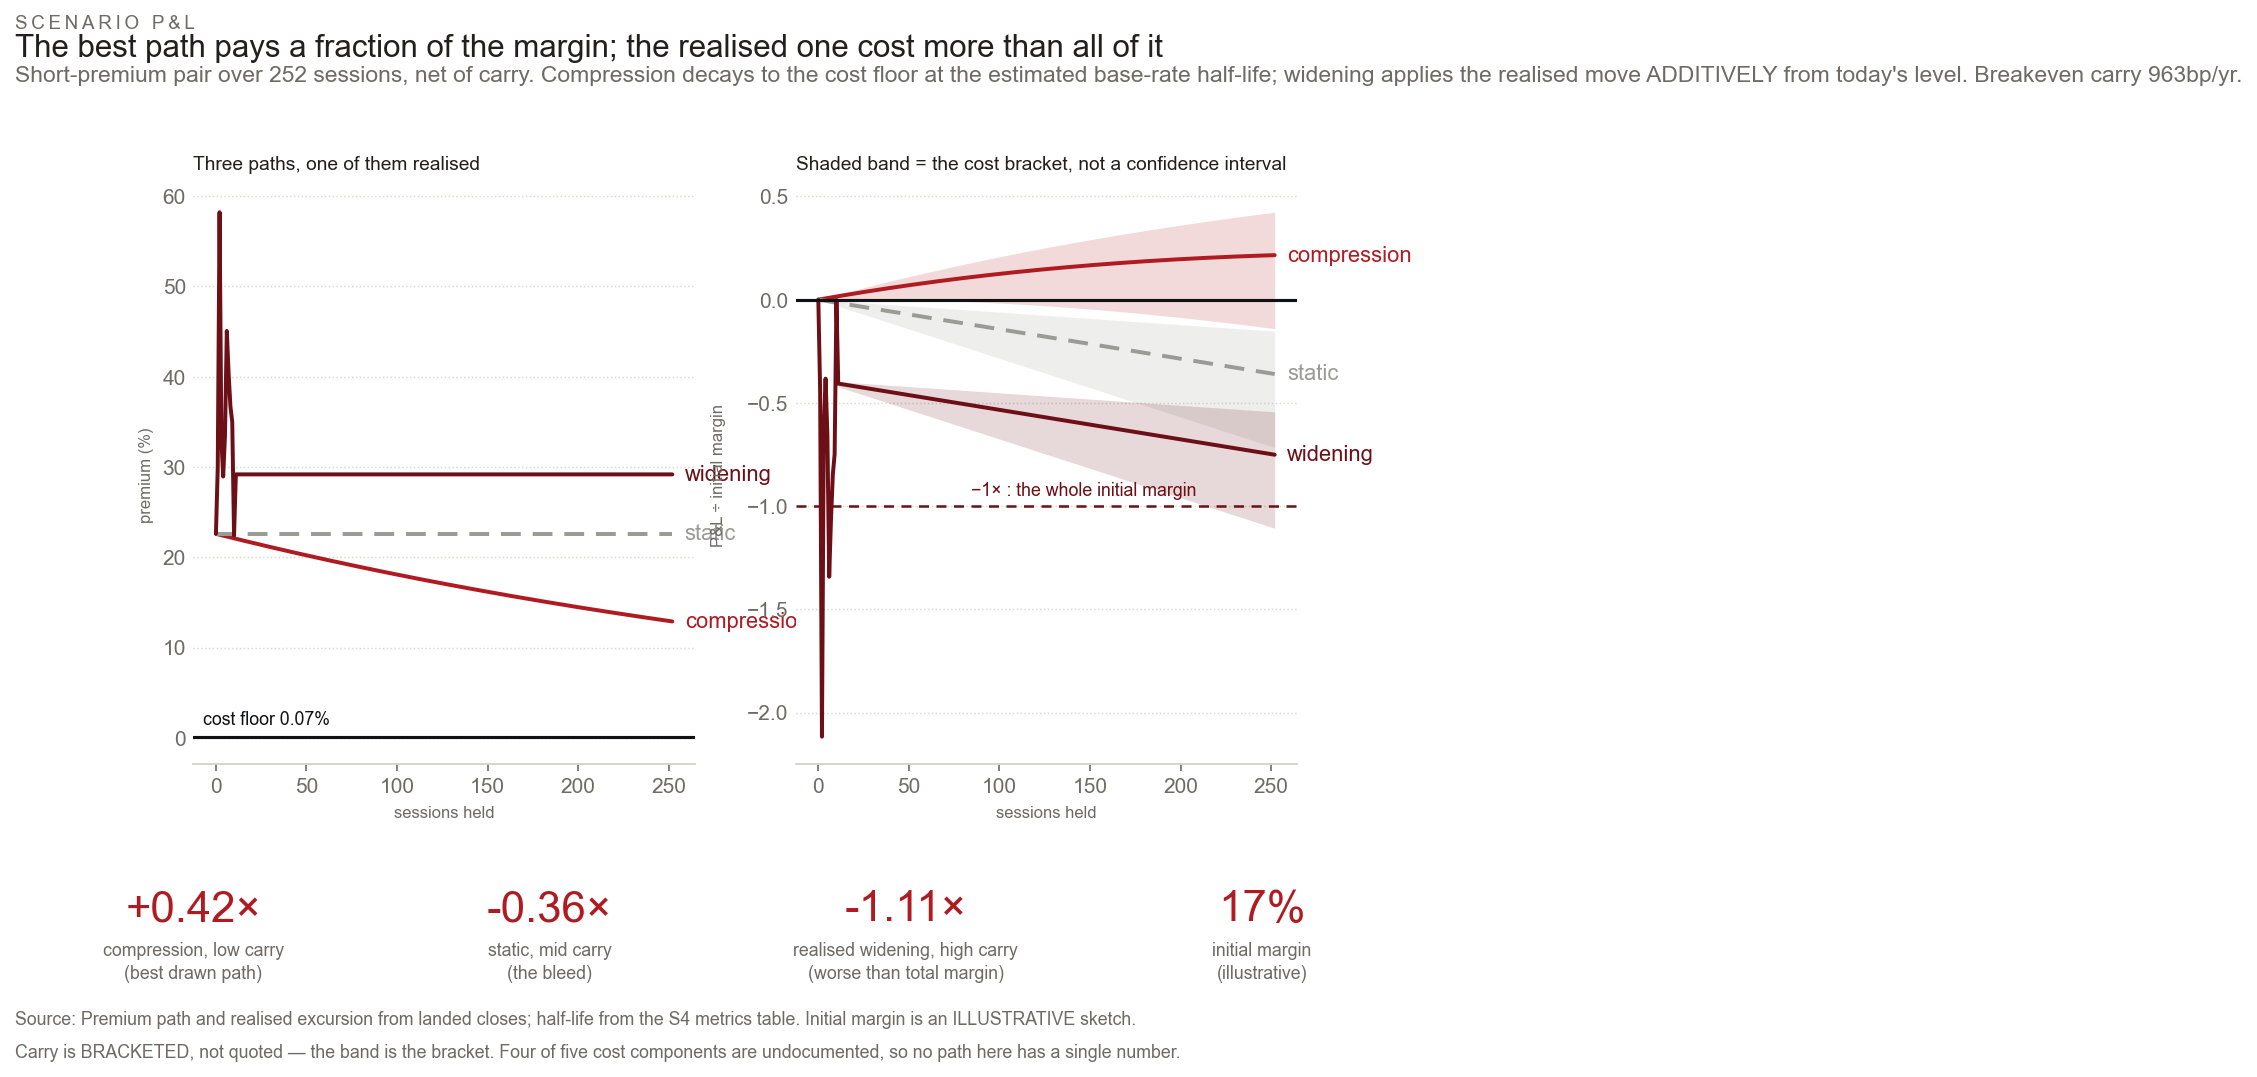

In [17]:
fig, _ = PANELS["P8_scenario_pnl"]()
fig;

In [18]:
Markdown(f'''
**Compression to the comparable's five-year mean is {PI - NORM:.0f} points.** Against
illustrative 20% initial margin that is the featured path. Half-compression is half of it. The
static path bleeds the carry at {LO:.0f}–{HI:.0f}bp/mo. The realised widening — what this pair
actually did in its first week — is on the same chart at the same scale, and it is why the risk
section exists.

We do not forecast which path happens. We price the financing and show you all three.
''')


**Compression to the comparable's five-year mean is 10 points.** Against
illustrative 20% initial margin that is the featured path. Half-compression is half of it. The
static path bleeds the carry at 7–70bp/mo. The realised widening — what this pair
actually did in its first week — is on the same chart at the same scale, and it is why the risk
section exists.

We do not forecast which path happens. We price the financing and show you all three.


## 7. Risk considerations — for the PM's assessment

In [19]:
Markdown(f'''
**The payoff is asymmetric.** Gain is capped by the cost floor. Loss is not capped by anything
on file, because the ceiling is the Company's decision rather than a rule.

**It has already moved hard.** The premium went **{SKW["excursion_pp"]:.0f} points against an
early seller in {SKW["sessions"]} sessions** — worse than the worst 252-day excursion
({EX.attrs["max_mae_pp"]:.0f} points) in 21.6 years of the comparable pair. That is realised,
not modelled.

**Wrong-way dynamics.** The event that closes the gap — an issuance — is also the event that
marks the position against you on the way there, and the borrow tightens into exactly that
state.

**Sizing, not stops.** A stop tight enough to bound loss fires on most winners; one loose
enough to leave winners alone does not bound loss. The risk budget is set by size, and the
appendix shows the distribution it should be set against. Exit paths are agreed at entry and
are in the appendix tree.
''')


**The payoff is asymmetric.** Gain is capped by the cost floor. Loss is not capped by anything
on file, because the ceiling is the Company's decision rather than a rule.

**It has already moved hard.** The premium went **36 points against an
early seller in 3 sessions** — worse than the worst 252-day excursion
(25 points) in 21.6 years of the comparable pair. That is realised,
not modelled.

**Wrong-way dynamics.** The event that closes the gap — an issuance — is also the event that
marks the position against you on the way there, and the borrow tightens into exactly that
state.

**Sizing, not stops.** A stop tight enough to bound loss fires on most winners; one loose
enough to leave winners alone does not bound loss. The risk budget is set by size, and the
appendix shows the distribution it should be set against. Exit paths are agreed at entry and
are in the appendix tree.


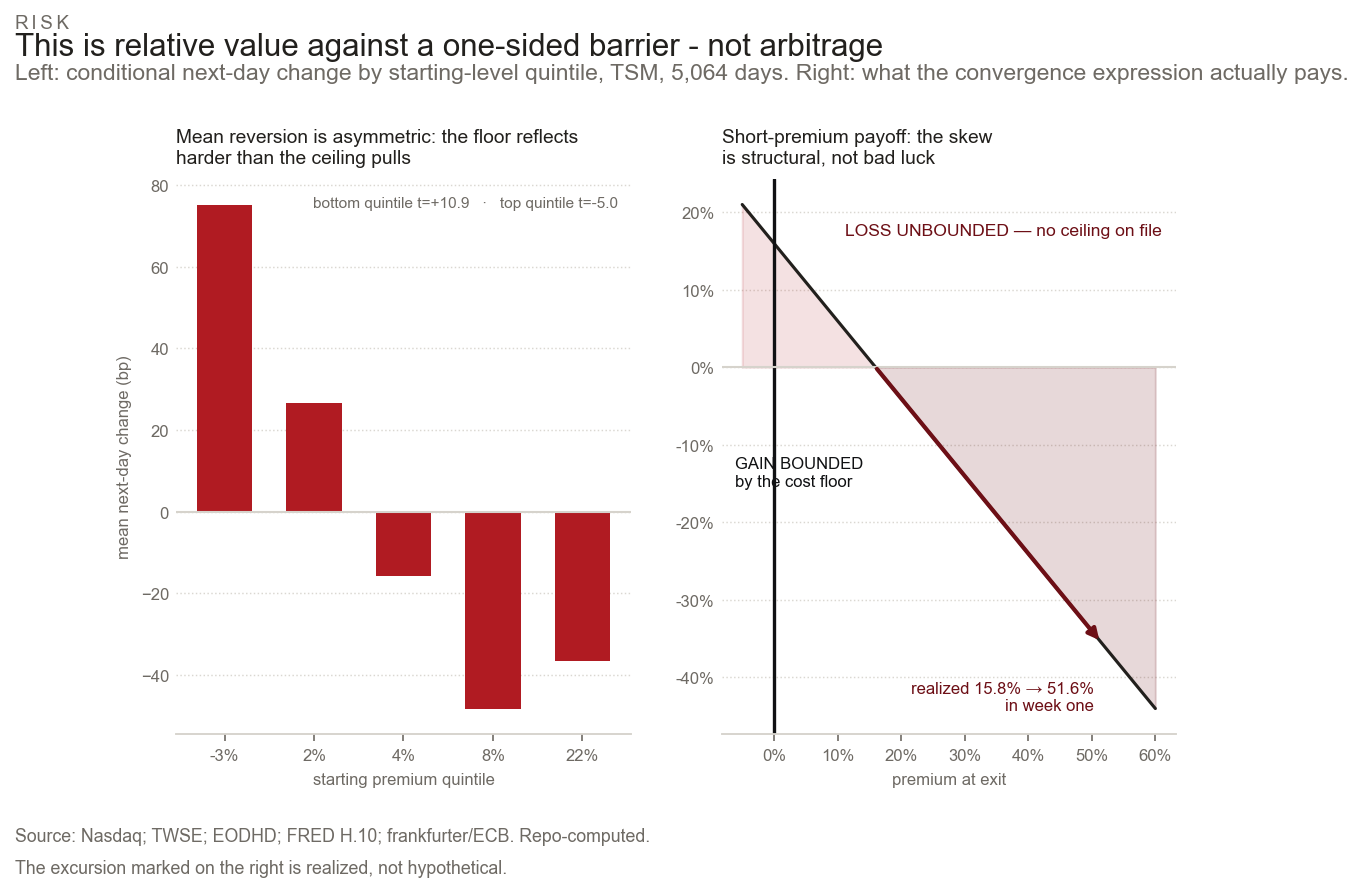

In [20]:
fig, _ = PANELS["P4a_payoff"]()
fig;

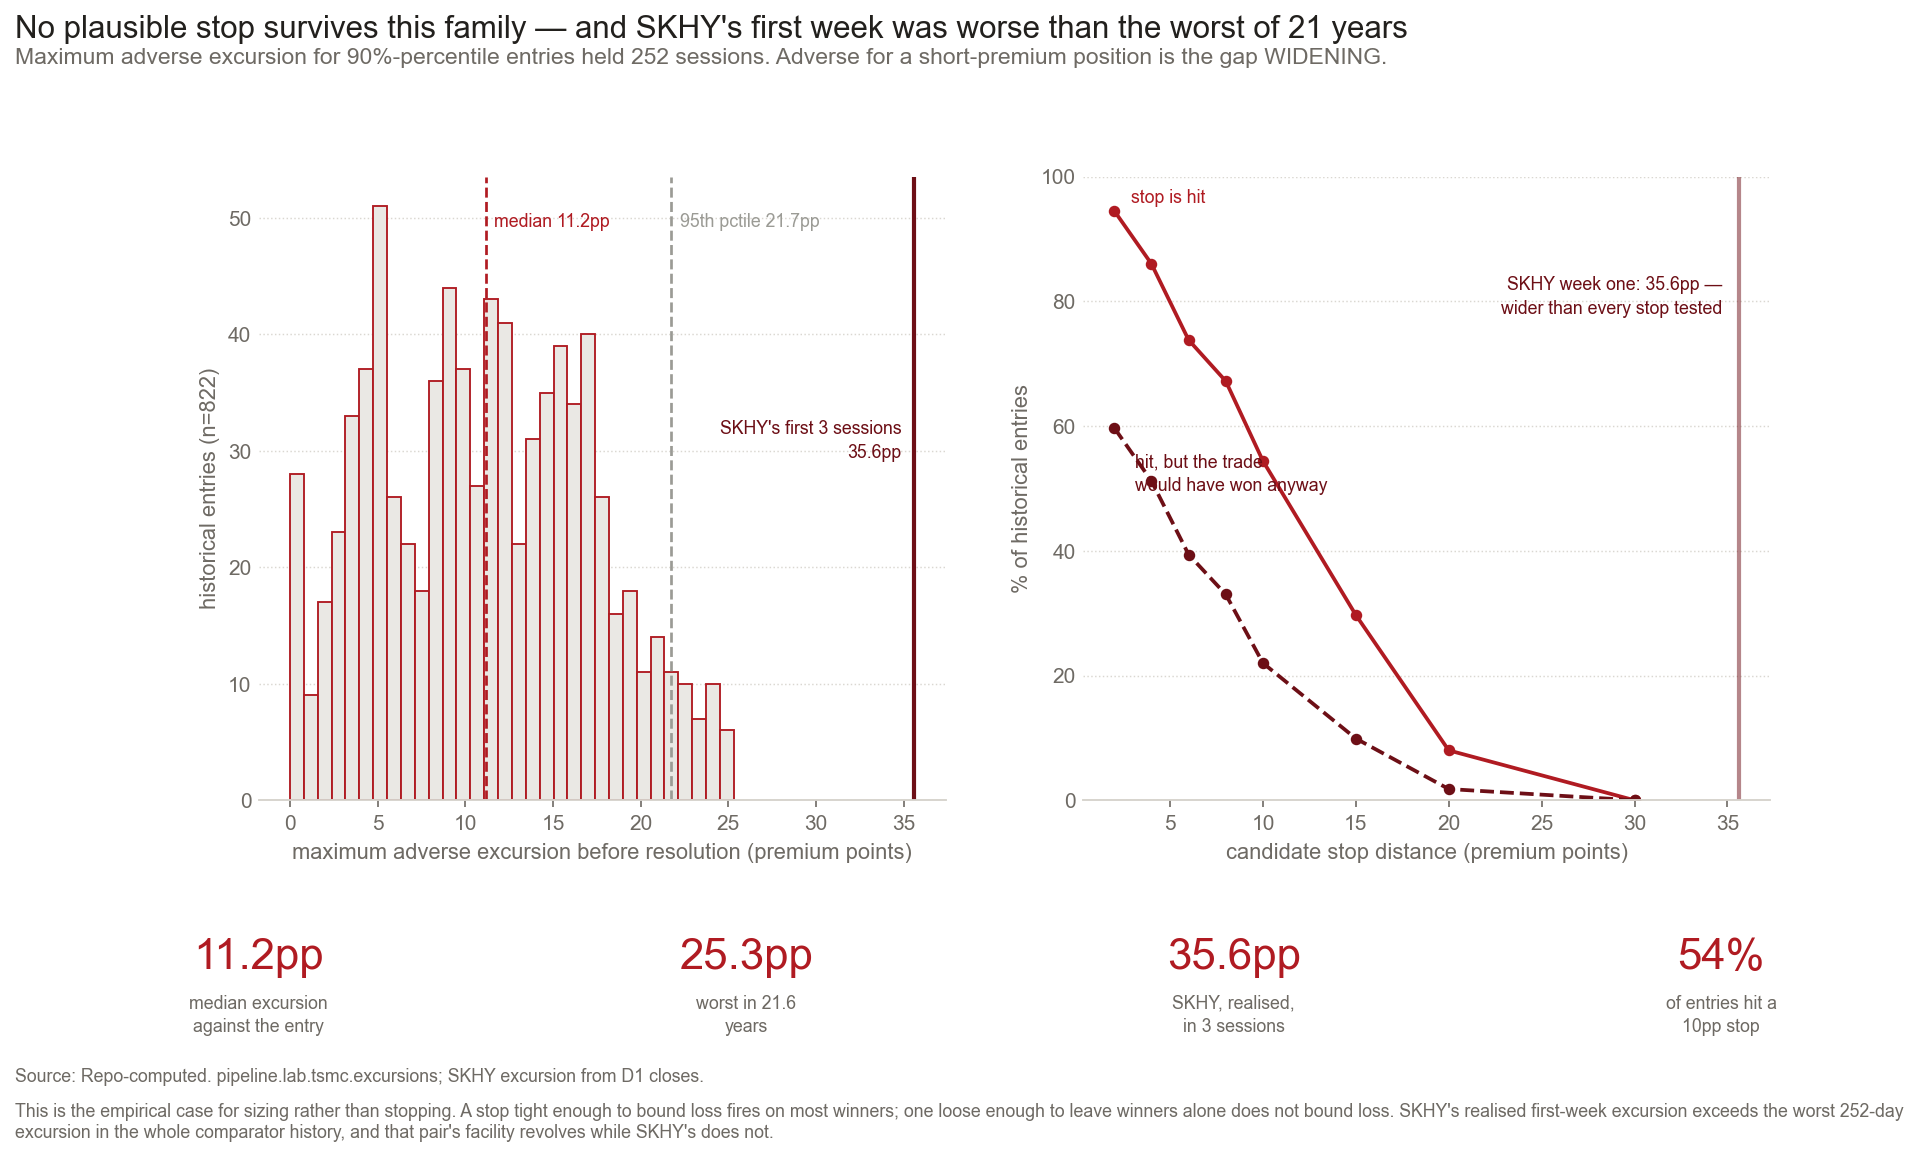

In [21]:
fig, _ = PANELS["P8d_lab_stops"]()
fig;

## 8. Monitoring, and the ask

**Weekly, you receive:** the premium and its move, the conversion valve's state, borrow
availability and cost, and the status of three registered watch items — an issuance disclosure,
a headroom print on the ISIN, and a Korean borrow-regime shift.

**The standby variant.** The same monitoring without a position, with our registered call
resolving 2026-10-31. It resolves in public whichever way it goes.

**The ask.** A first conversation on financing levels and borrow availability at $100mm, and
whether the cross-margined structure fits your existing documentation.

---

### Appendix

Referenced rather than re-rendered, so no figure exists in two versions.

| | |
|---|---|
| Measurement discipline | [02](02_premium_anatomy.ipynb) — four π variants, the FX-source spread, the shared-date rule |
| The panel and its limits | [03](03_comparator_panel.ipynb) — three regimes, corporate-action QA, calendar policy, and the withheld PLDT classification |
| The 21.6-year distributions | [09](09_tsmc_lab.ipynb) — census, entry outcomes, excursions, the FX channel per era |
| We tested the timing | [06](06_complexity_ledger.ipynb) — parsimony against complexity; the shallow model won, so there is no model behind this pitch |
| Netting under stress | [01](01_client_note.ipynb) — the margin path through the realised week |
| The exit tree | [08](08_pitch_logic.ipynb) — five monitors, three routes |
| Breakeven surface | [10](10_financing.ipynb) — the carry opened into components |
| H6 in detail | [07](07_macro_environment.ipynb) — registered direction, both tests, the pooled spec |
| Methodology and sources | `docs/data_sources.md`, `preregistration/` |

---

*Informational only. Not advice, not a recommendation, not a solicitation. The ADR borrow
spread is a bracketed assumption pending a desk quote and the cross-currency basis is unmeasured;
margining is illustrative and real schedules are the desk's to quote. Past behaviour of a
comparable pair is characterisation of a regime family, not a forecast of this one.*